# GFDL ocean heat content: forced-ocean parameterization comparison

Extends the global-mean ocean potential temperature/salinity time series
from `gfdl_time_series.ipynb` with a **depth breakdown**: volume-averaged
temperature and salinity over five depth ranges (surface, 0-300 m,
300-700 m, 700-2000 m, > 2000 m) plus the full-depth global mean, for each
of GFDL's 4 forced-ocean experiments -- mirroring CESM's
`ocean_heat_content.ipynb`.

`Experiment.compute_ocean_heat_content()` is fully generic (reads
`thetao`/`so`/`volcello` from the T/S shim's own `*.mom6.h.z.*.nc` files,
the same ones `mom6_tools.TS_levels` reads) and required no GFDL-specific
adaptation -- already run for all 4 experiments (see
`data/gfdl_1988_2012/gfdl_*_ocean_heat_content.nc`), covering each
experiment's full available record (not just the 1988-2012 window), to
match the existing global-mean time series convention.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import matplotlib.pyplot as plt
import nc_time_axis  # lets matplotlib plot GFDL's cftime (julian calendar) axis directly

from experiment import Experiment, layer_thickness_from_midpoints

%matplotlib inline

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 16})

REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
GFDL_DIR = os.path.join(REPO, 'data', 'gfdl_1988_2012')

print('REPO     =', REPO)
print('GFDL_DIR =', GFDL_DIR)

REPO     = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
GFDL_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/gfdl_1988_2012


In [2]:
experiment_defs = [
    ('gfdl_CTRL',       GFDL_DIR),
    ('gfdl_bANN',       GFDL_DIR),
    ('gfdl_uANN',       GFDL_DIR),
    ('gfdl_bANN_uANN',  GFDL_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

names = list(exps.keys())
CTRL = 'gfdl_CTRL'

LABELS = {
    'gfdl_CTRL':      'CTRL',
    'gfdl_bANN':      'bANN',
    'gfdl_uANN':      'uANN',
    'gfdl_bANN_uANN': 'bANN_uANN',
}
COLORS = {
    'gfdl_CTRL':      'k',
    'gfdl_bANN':      '#0072B2',
    'gfdl_uANN':      '#E69F00',
    'gfdl_bANN_uANN': '#009E73',
}

print('Initialized:', names)

[gfdl_CTRL] casename=gfdl_CTRL, rundir=/glade/derecho/scratch/pavelp/GFDL/CTRL/cesm_format/run


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


MOM6 grid successfully loaded... 



[gfdl_bANN] casename=gfdl_bANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN/cesm_format/run
MOM6 grid successfully loaded... 



[gfdl_uANN] casename=gfdl_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/uANN/cesm_format/run
MOM6 grid successfully loaded... 



[gfdl_bANN_uANN] casename=gfdl_bANN_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN_uANN/cesm_format/run
MOM6 grid successfully loaded... 

Initialized: ['gfdl_CTRL', 'gfdl_bANN', 'gfdl_uANN', 'gfdl_bANN_uANN']


# 1. Volume-averaged temperature and salinity by depth range

Monthly volume-averaged potential temperature (`thetao_*`) and salinity
(`so_*`) for the full depth column plus four sub-ranges, from
`Experiment.compute_ocean_heat_content()`. Each panel overlays all 4
experiments (CTRL in black) against the WOA-2018 reference for that depth
range (dashed gray).

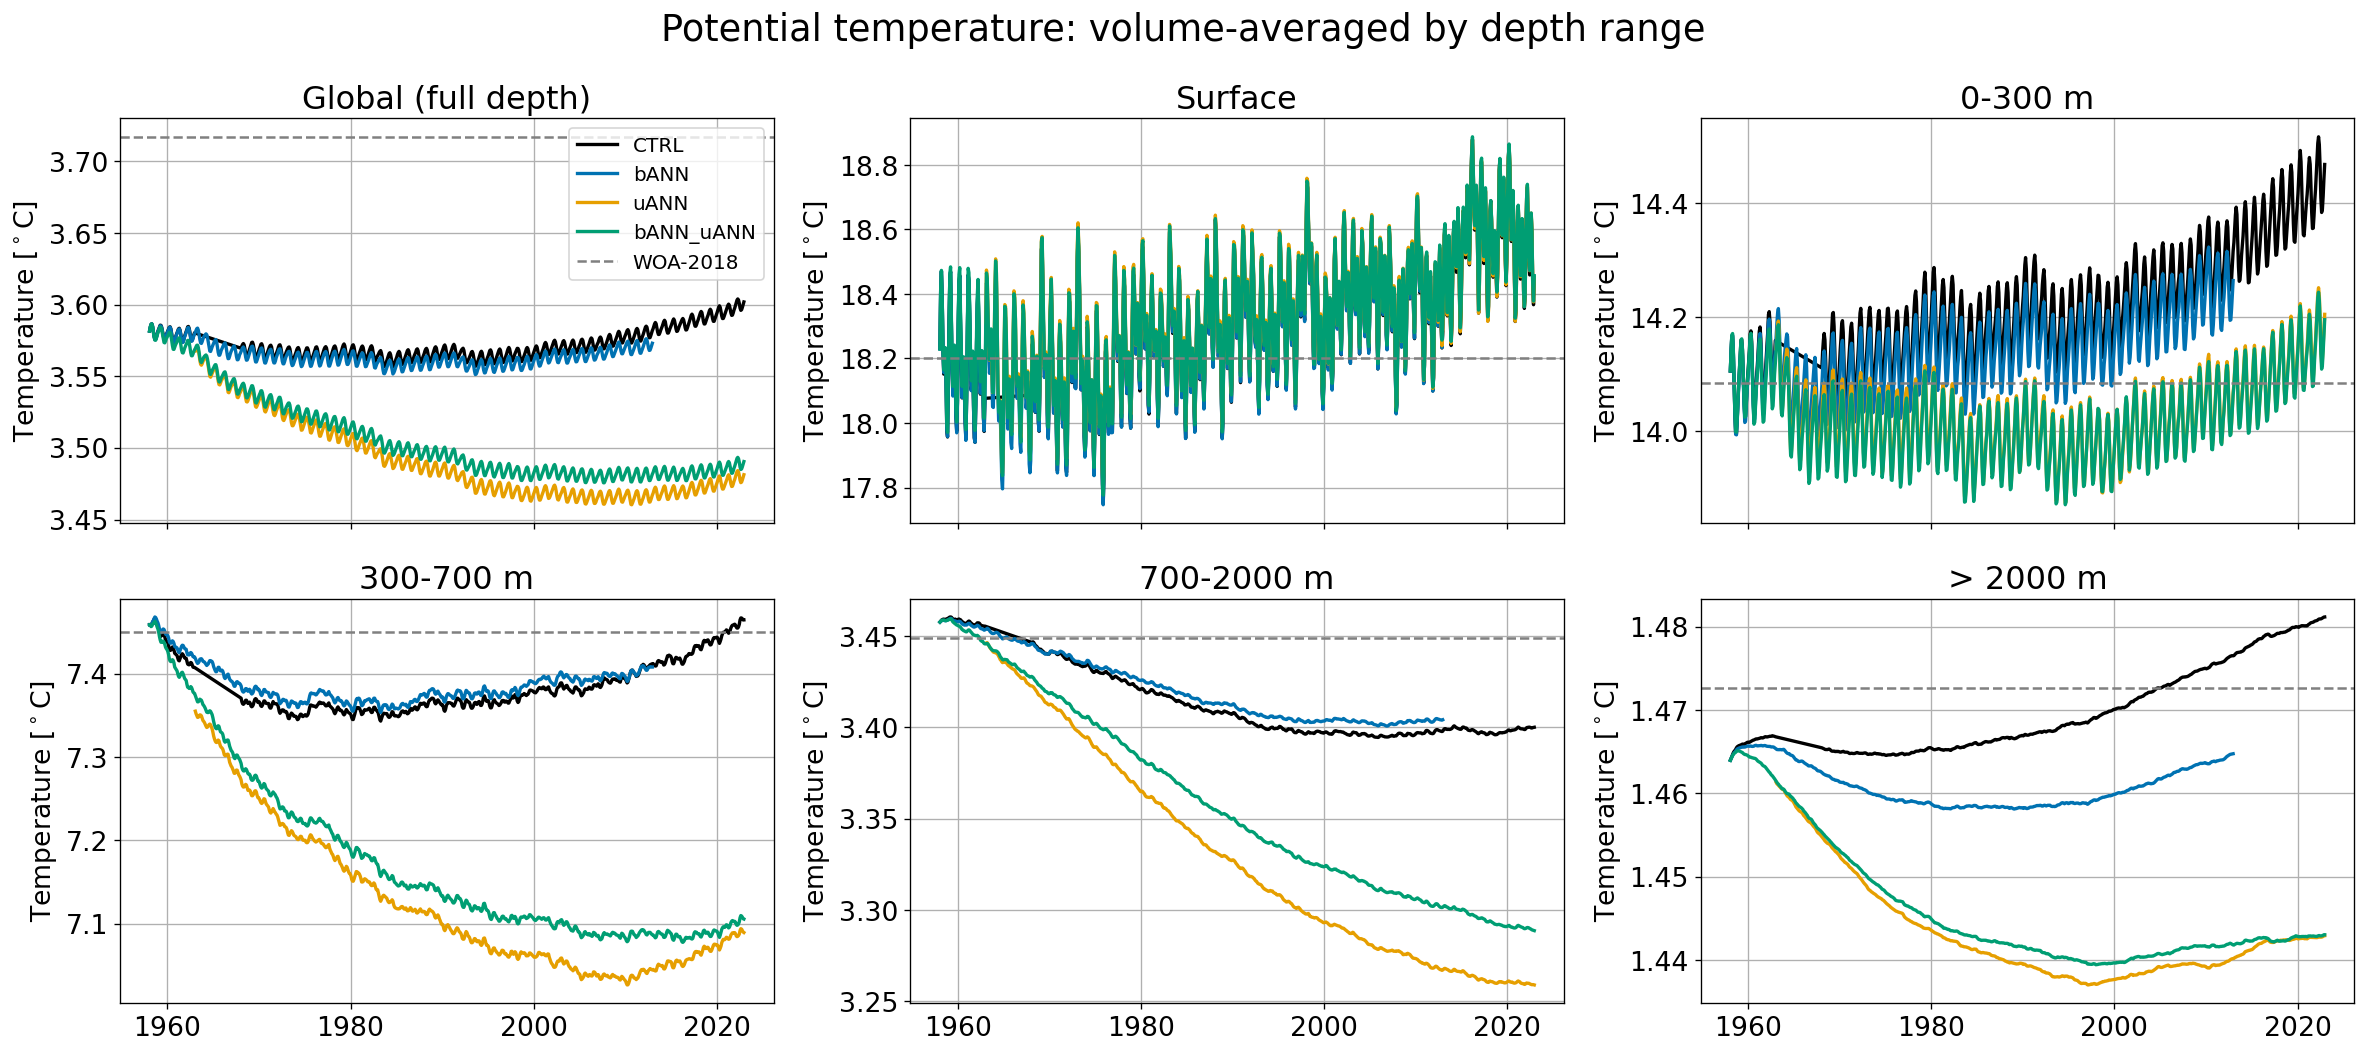

In [3]:
DEPTH_RANGES = [('global', None, None), ('surface', None, None)] + Experiment.OCEAN_HEAT_CONTENT_DEPTH_RANGES
DEPTH_TITLES = {
    'global': 'Global (full depth)',
    'surface': 'Surface',
    '0_300m': '0-300 m',
    '300_700m': '300-700 m',
    '700_2000m': '700-2000 m',
    '2000m_plus': '> 2000 m',
}


def global_mean_timeseries(exp, var):
    # Full-depth volume-mean timeseries, derived from the cached (time,
    # z_l) profiles -- no re-reading of the raw history.
    ds = exp.ocean_heat_content()
    tprof = ds[f'{var}_volcello_profile']
    vprof = ds['volcello_profile']
    return tprof.sum('z_l') / vprof.sum('z_l')


def woa_reference(exp, var, label, lo, hi):
    # Volume- (or area-, for surface) weighted WOA-2018 reference for one
    # depth range, recovered as model - bias from the cached
    # *_thetao_time_mean.nc / *_so_time_mean.nc file.
    ds = exp.thetao() if var == 'thetao' else exp.so()
    obs = ds[var] - ds[f'{var}_bias']
    area = exp.area
    if label == 'surface':
        surf = obs.isel(z_l=0)
        return float((surf * area).sum() / area.where(surf.notnull()).sum())
    dz = layer_thickness_from_midpoints(obs['z_l'])
    if label == 'global':
        weight = (dz * area).where(obs.notnull())
        return float((obs * weight).sum() / weight.sum())
    if lo is None:
        zmask = obs['z_l'] <= hi
    elif hi is None:
        zmask = obs['z_l'] > lo
    else:
        zmask = (obs['z_l'] > lo) & (obs['z_l'] <= hi)
    z_sel = obs['z_l'].where(zmask, drop=True)
    obs_bin = obs.sel(z_l=z_sel)
    weight = (dz.sel(z_l=z_sel) * area).where(obs_bin.notnull())
    return float((obs_bin * weight).sum() / weight.sum())


def plot_depth_profile(var, long_name, unit):
    # 2x3 grid (global, surface, 0-300m / 300-700m, 700-2000m, >2000m),
    # all 4 experiments overlaid per panel (CTRL black), WOA-2018 dashed.
    fig, axes = plt.subplots(2, 3, figsize=(20, 9), dpi=120, sharex=True)
    for row_col, (label, lo, hi) in zip(
            [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2)], DEPTH_RANGES):
        ax = axes[row_col]
        woa_val = woa_reference(exps[CTRL], var, label, lo, hi)
        for name in names:
            if label == 'global':
                da = global_mean_timeseries(exps[name], var)
            else:
                da = exps[name].ocean_heat_content()[f'{var}_{label}']
            da.plot(ax=ax, label=LABELS[name], lw=2, color=COLORS[name])
        ax.axhline(woa_val, color='gray', ls='--', lw=1.5, label='WOA-2018')
        ax.set_title(DEPTH_TITLES[label])
        ax.set_xlabel('')
        ax.set_ylabel(unit)
        ax.grid(True)
        if row_col == (0, 0):
            ax.legend(loc='best', fontsize=12)
    fig.suptitle(f'{long_name}: volume-averaged by depth range', fontsize=22)
    plt.tight_layout()
    plt.show()


plot_depth_profile('thetao', 'Potential temperature', r'Temperature [$^\circ$C]')

## Salinity

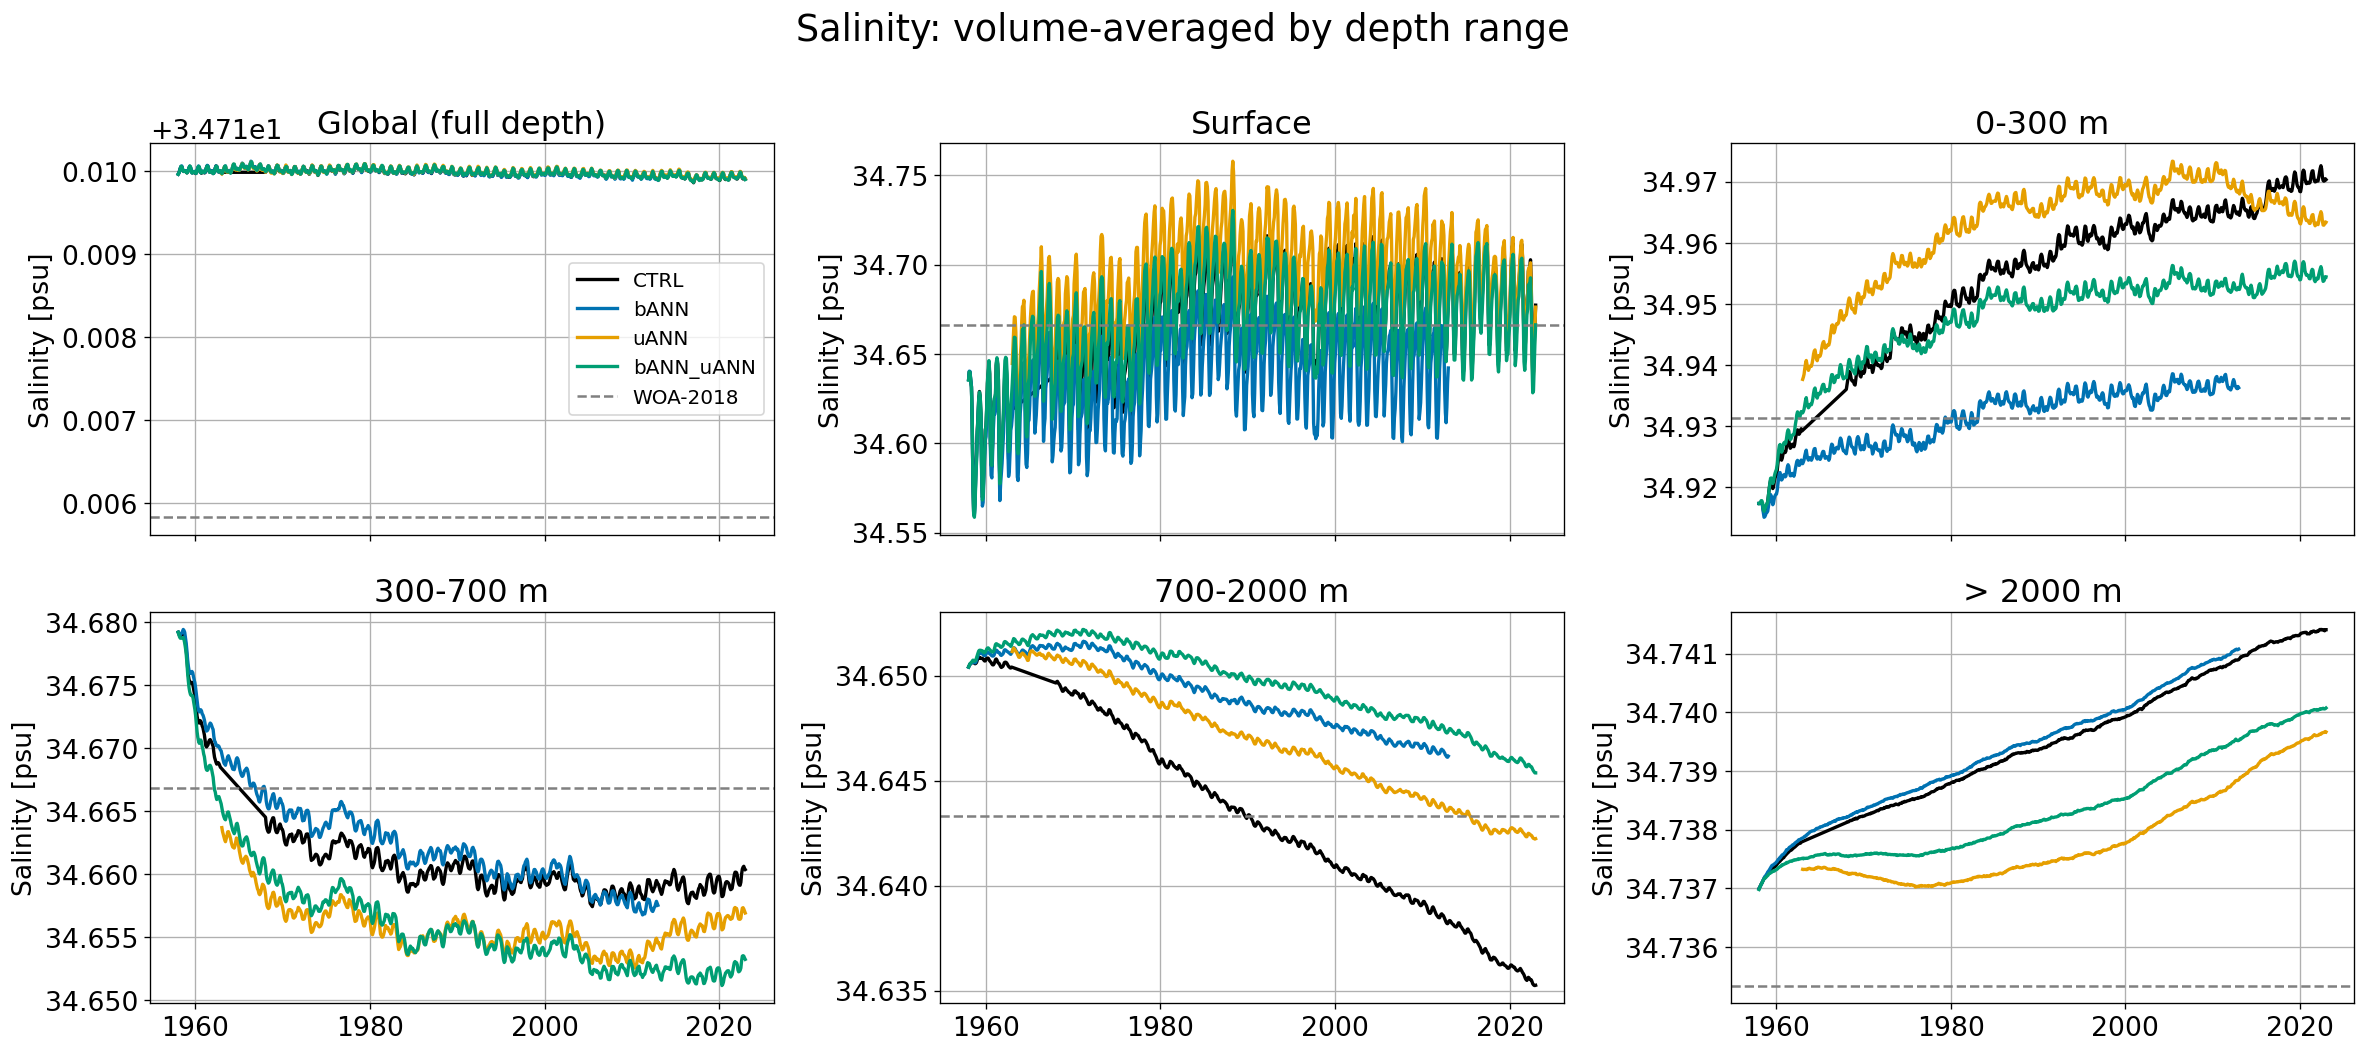

In [4]:
plot_depth_profile('so', 'Salinity', 'Salinity [psu]')